<a href="https://colab.research.google.com/github/rounak-roy-2025/Finance101/blob/Volatiltiy/VIXApplication_Analysis_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.0 MB/s eta 0:00:00
NIFTY 50 VOLATILITY ANALYSIS

[1/6] Fetching Nifty 50 data...
Data points: 1357
Date range: 2020-07-28 to 2026-01-19
Summary Statistics:
count    1357.000000
mean        0.065297
std         0.888309
min        -5.929360
25%        -0.394250
50%         0.083556
75%         0.589362
max         4.742351
Name: Returns, dtype: float64

[2/6] Calculating Rolling Volatility and MAPE...
MAPE (Mean Absolute Percentage Error): 0.0369 (3.69%)

[3/6] Fitting GARCH(1,1) model...
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1677.72
Distribution:                  Normal   AIC:                           3363.44
Method:            Maximum Likelihood   BIC:      

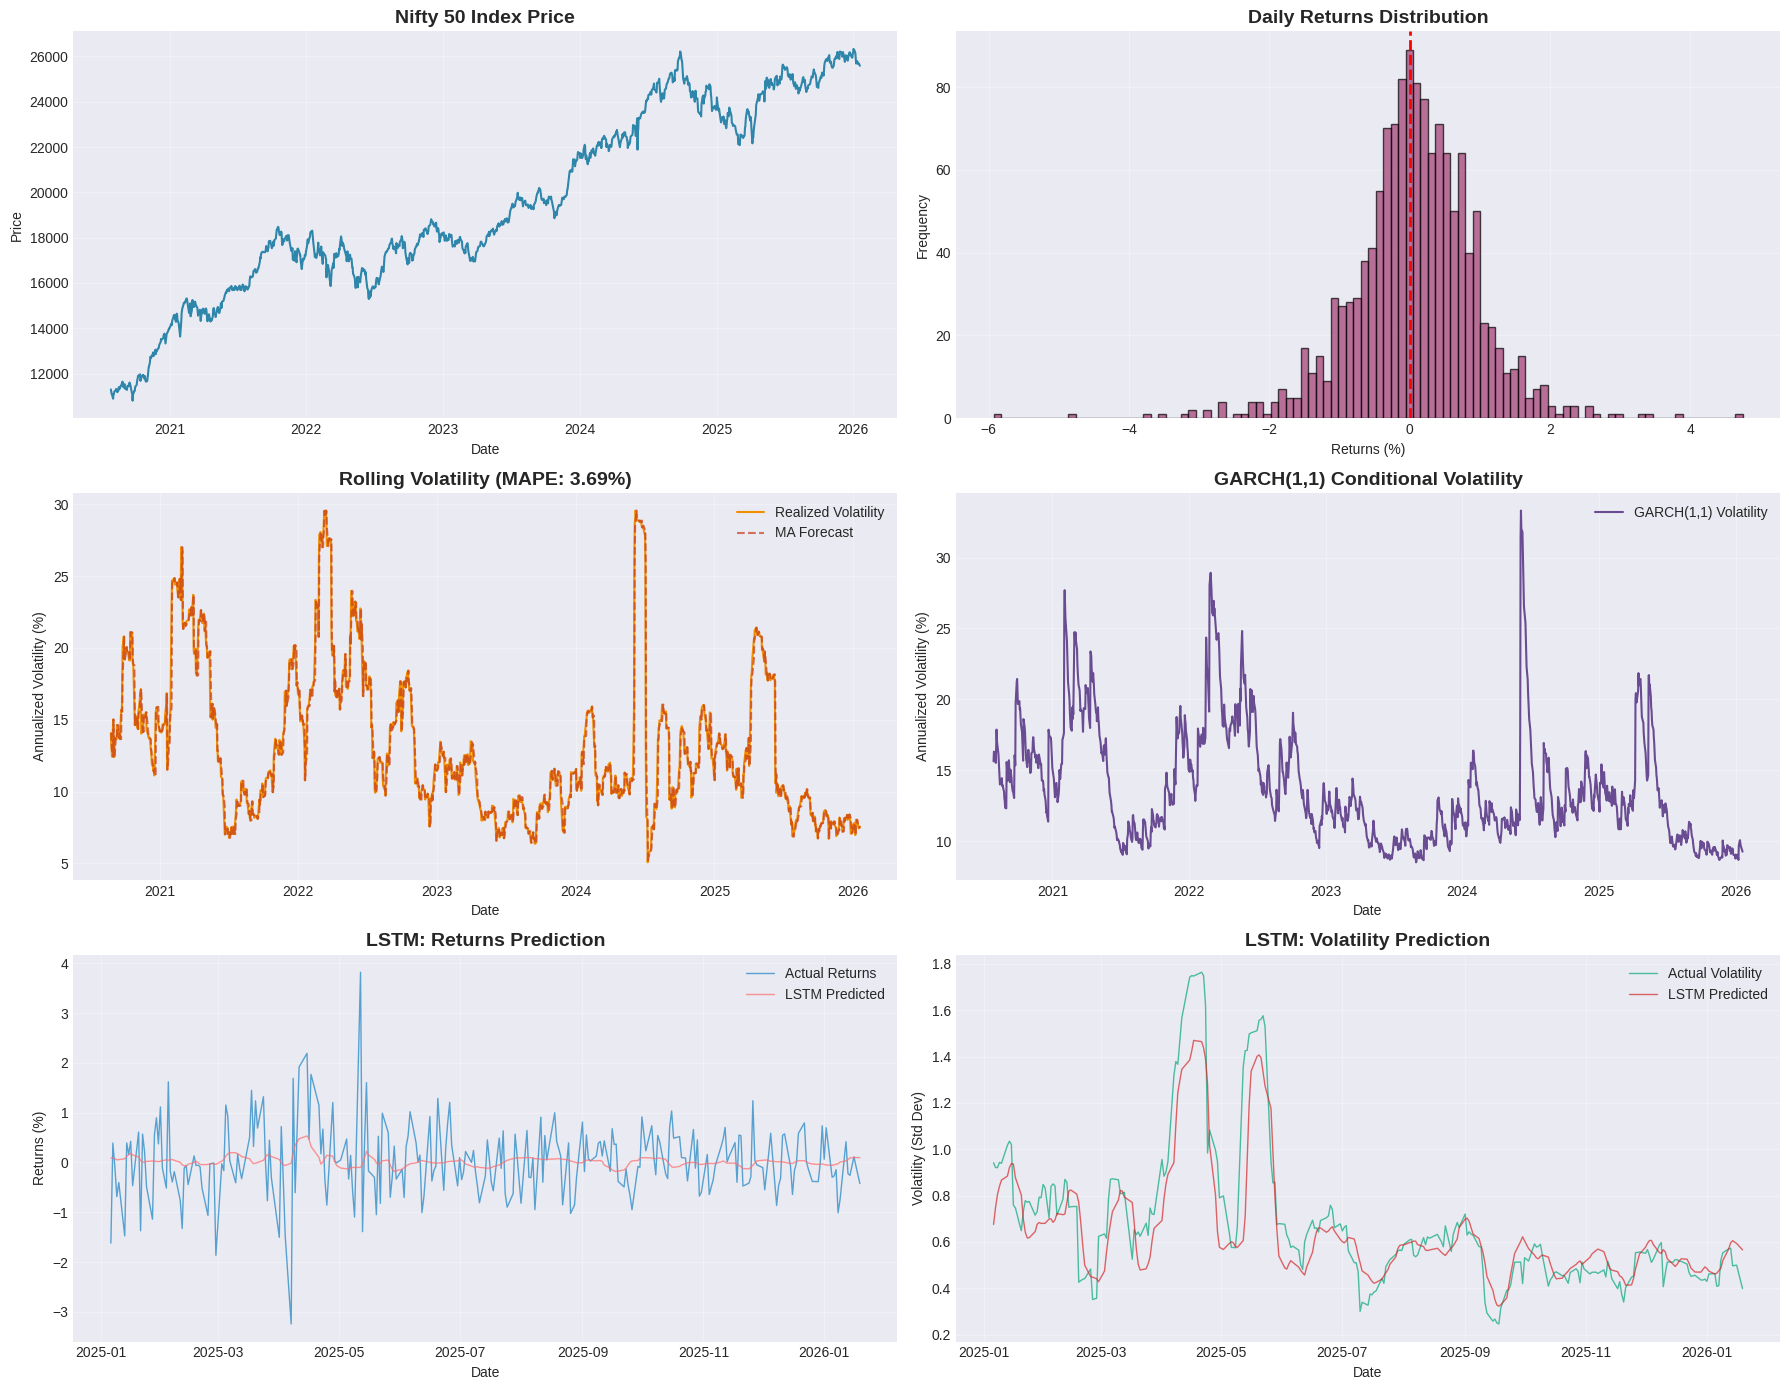


[6/6] Creating comprehensive comparison...


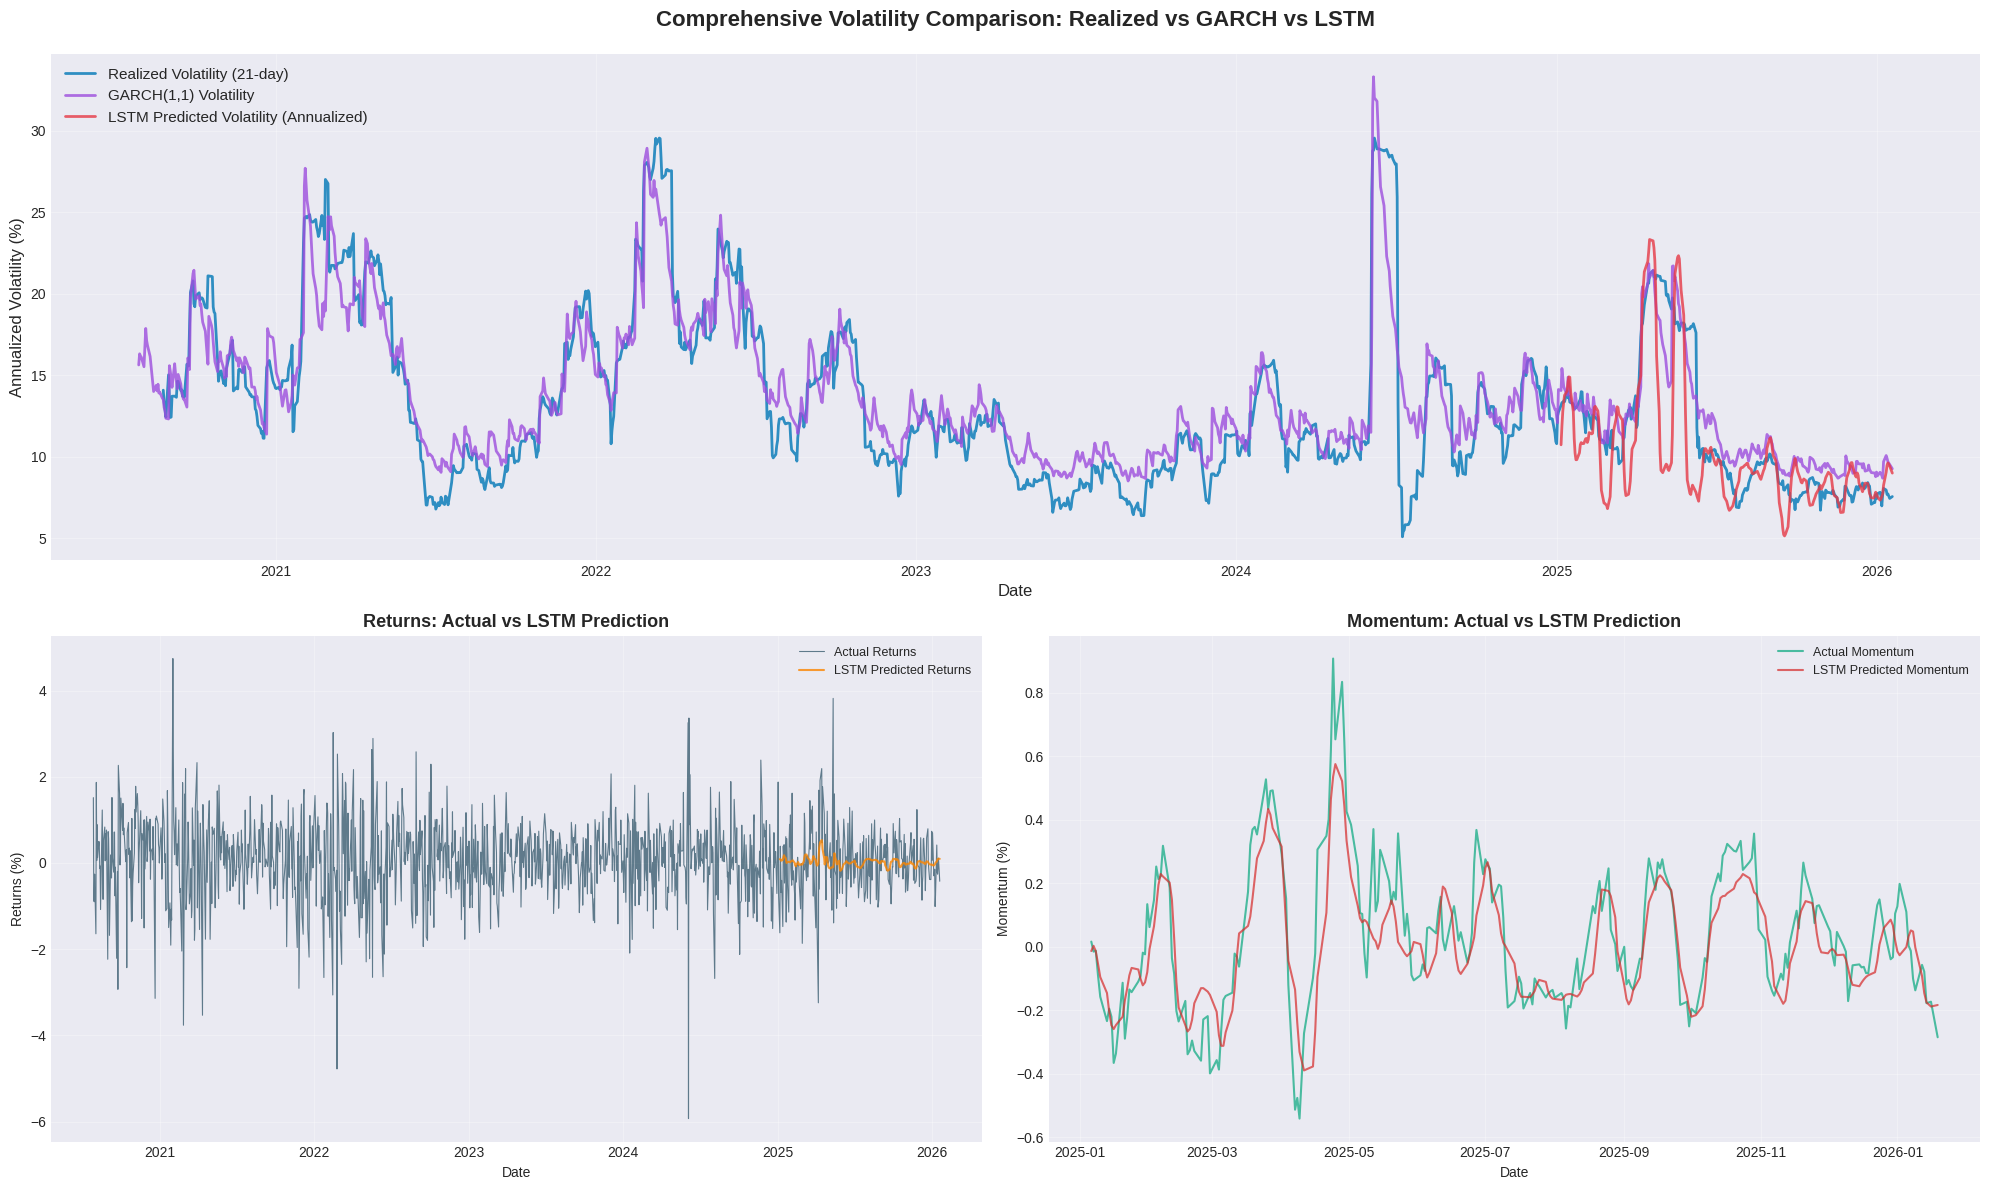


SUMMARY STATISTICS

Volatility Comparison (Annualized %):
         Metric  Realized     GARCH      LSTM
Mean Volatility 13.209645 13.729890 10.145159
 Std Volatility  5.126867  4.032520  3.645539
 Min Volatility  5.077095  8.503884  5.131812
 Max Volatility 29.555117 33.317301 23.327177

MAPE for Volatility Forecast: 3.69%
LSTM Test MAE: 0.039728

Analysis Complete! Charts saved as PNG files.


In [ ]:
"""
Nifty 50 Volatility Analysis using MAPE, ARCH/GARCH, and LSTM
Analyzes last 5+ years of data and compares all methods
"""

# Install required packages
!pip install yfinance arch tensorflow scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Data and modeling
import yfinance as yf
from arch import arch_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("NIFTY 50 VOLATILITY ANALYSIS")
print("=" * 80)

# ============================================================================
# 1. DATA COLLECTION
# ============================================================================
print("\n[1/6] Fetching Nifty 50 data...")

# Get data for last 5+ years
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365 + 180)  # 5.5 years for safety

# Download Nifty 50 data (^NSEI is the Yahoo Finance ticker)
nifty_data = yf.download('^NSEI', start=start_date, end=end_date, progress=False)

# Use Close price as specified
nifty_data = nifty_data[['Close']].copy()
nifty_data.columns = ['Close']

# Calculate returns
nifty_data['Returns'] = nifty_data['Close'].pct_change() * 100
nifty_data = nifty_data.dropna()

print(f"Data points: {len(nifty_data)}")
print(f"Date range: {nifty_data.index[0].date()} to {nifty_data.index[-1].date()}")
print(f"Summary Statistics:")
print(nifty_data['Returns'].describe())

# ============================================================================
# 2. ROLLING VOLATILITY (REALIZED) AND MAPE CALCULATION
# ============================================================================
print("\n[2/6] Calculating Rolling Volatility and MAPE...")

# Calculate rolling volatility (21-day window for monthly volatility)
window = 21
nifty_data['Realized_Vol'] = nifty_data['Returns'].rolling(window=window).std() * np.sqrt(252)

# Simple moving average forecast for MAPE calculation
nifty_data['Vol_Forecast_MA'] = nifty_data['Realized_Vol'].shift(1)

# Remove NaN values for MAPE calculation
valid_data = nifty_data[['Realized_Vol', 'Vol_Forecast_MA']].dropna()

# Calculate MAPE
mape_value = mean_absolute_percentage_error(
    valid_data['Realized_Vol'],
    valid_data['Vol_Forecast_MA']
)

print(f"MAPE (Mean Absolute Percentage Error): {mape_value:.4f} ({mape_value*100:.2f}%)")

# ============================================================================
# 3. ARCH/GARCH MODELING
# ============================================================================
print("\n[3/6] Fitting GARCH(1,1) model...")

# Prepare returns for GARCH (remove mean)
returns_garch = nifty_data['Returns'].dropna()

# Fit GARCH(1,1) model
garch_model = arch_model(returns_garch, vol='Garch', p=1, q=1, rescale=False)
garch_fitted = garch_model.fit(disp='off')

print(garch_fitted.summary())

# Extract conditional volatility
garch_vol = garch_fitted.conditional_volatility
garch_vol_annualized = garch_vol * np.sqrt(252)

# Align with original data
nifty_data['GARCH_Vol'] = np.nan
nifty_data.loc[garch_vol_annualized.index, 'GARCH_Vol'] = garch_vol_annualized

# ============================================================================
# 4. LSTM MODEL FOR RETURNS, MOMENTUM, AND VOLATILITY
# ============================================================================
print("\n[4/6] Training LSTM model...")

# Prepare features
feature_data = nifty_data[['Returns', 'Close']].copy()
feature_data['Momentum'] = feature_data['Returns'].rolling(window=10).mean()
feature_data['Volatility'] = feature_data['Returns'].rolling(window=10).std()
feature_data = feature_data.dropna()

# Normalize data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(feature_data)

# Create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

# Train-test split (80-20)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Build LSTM model
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(seq_length, X.shape[2])),
    Dropout(0.2),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(X.shape[2])
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

print("\nTraining LSTM...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=0
)

# Make predictions
predictions = model.predict(X_test, verbose=0)
predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test)

# Create DataFrame for LSTM results
lstm_dates = feature_data.index[seq_length + split_idx:]
lstm_results = pd.DataFrame({
    'Returns_Actual': y_test_rescaled[:, 0],
    'Returns_Pred': predictions_rescaled[:, 0],
    'Momentum_Actual': y_test_rescaled[:, 2],
    'Momentum_Pred': predictions_rescaled[:, 2],
    'Volatility_Actual': y_test_rescaled[:, 3],
    'Volatility_Pred': predictions_rescaled[:, 3]
}, index=lstm_dates)

print(f"\nLSTM Training Loss: {history.history['loss'][-1]:.6f}")
print(f"LSTM Validation Loss: {history.history['val_loss'][-1]:.6f}")

# ============================================================================
# 5. PLOTTING INDIVIDUAL RESULTS
# ============================================================================
print("\n[5/6] Creating visualizations...")

fig = plt.figure(figsize=(18, 14))

# Plot 1: Nifty 50 Price
ax1 = plt.subplot(3, 2, 1)
ax1.plot(nifty_data.index, nifty_data['Close'], linewidth=1.5, color='#2E86AB')
ax1.set_title('Nifty 50 Index Price', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.grid(True, alpha=0.3)

# Plot 2: Returns Distribution
ax2 = plt.subplot(3, 2, 2)
ax2.hist(nifty_data['Returns'], bins=100, alpha=0.7, color='#A23B72', edgecolor='black')
ax2.set_title('Daily Returns Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Returns (%)')
ax2.set_ylabel('Frequency')
ax2.axvline(0, color='red', linestyle='--', linewidth=2)
ax2.grid(True, alpha=0.3)

# Plot 3: Rolling Volatility with MAPE
ax3 = plt.subplot(3, 2, 3)
ax3.plot(nifty_data.index, nifty_data['Realized_Vol'],
         linewidth=1.5, label='Realized Volatility', color='#F18F01')
ax3.plot(nifty_data.index, nifty_data['Vol_Forecast_MA'],
         linewidth=1.5, label='MA Forecast', alpha=0.7, linestyle='--', color='#C73E1D')
ax3.set_title(f'Rolling Volatility (MAPE: {mape_value*100:.2f}%)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Annualized Volatility (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: GARCH Volatility
ax4 = plt.subplot(3, 2, 4)
ax4.plot(nifty_data.index, nifty_data['GARCH_Vol'],
         linewidth=1.5, color='#6A4C93', label='GARCH(1,1) Volatility')
ax4.set_title('GARCH(1,1) Conditional Volatility', fontsize=14, fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Annualized Volatility (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: LSTM Returns Prediction
ax5 = plt.subplot(3, 2, 5)
ax5.plot(lstm_results.index, lstm_results['Returns_Actual'],
         linewidth=1, label='Actual Returns', alpha=0.7, color='#1982C4')
ax5.plot(lstm_results.index, lstm_results['Returns_Pred'],
         linewidth=1, label='LSTM Predicted', alpha=0.7, color='#FF6B6B')
ax5.set_title('LSTM: Returns Prediction', fontsize=14, fontweight='bold')
ax5.set_xlabel('Date')
ax5.set_ylabel('Returns (%)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: LSTM Volatility Prediction
ax6 = plt.subplot(3, 2, 6)
ax6.plot(lstm_results.index, lstm_results['Volatility_Actual'],
         linewidth=1, label='Actual Volatility', alpha=0.7, color='#06A77D')
ax6.plot(lstm_results.index, lstm_results['Volatility_Pred'],
         linewidth=1, label='LSTM Predicted', alpha=0.7, color='#D62828')
ax6.set_title('LSTM: Volatility Prediction', fontsize=14, fontweight='bold')
ax6.set_xlabel('Date')
ax6.set_ylabel('Volatility (Std Dev)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nifty50_individual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. COMPREHENSIVE COMPARISON
# ============================================================================
print("\n[6/6] Creating comprehensive comparison...")

fig_comp = plt.figure(figsize=(20, 12))

# Comprehensive volatility comparison
ax_main = plt.subplot(2, 1, 1)
ax_main.plot(nifty_data.index, nifty_data['Realized_Vol'],
            linewidth=2, label='Realized Volatility (21-day)', color='#0077B6', alpha=0.8)
ax_main.plot(nifty_data.index, nifty_data['GARCH_Vol'],
            linewidth=2, label='GARCH(1,1) Volatility', color='#9D4EDD', alpha=0.8)
ax_main.plot(lstm_results.index, lstm_results['Volatility_Pred'] * np.sqrt(252),
            linewidth=2, label='LSTM Predicted Volatility (Annualized)', color='#E63946', alpha=0.8)

ax_main.set_title('Comprehensive Volatility Comparison: Realized vs GARCH vs LSTM',
                  fontsize=16, fontweight='bold', pad=20)
ax_main.set_xlabel('Date', fontsize=12)
ax_main.set_ylabel('Annualized Volatility (%)', fontsize=12)
ax_main.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax_main.grid(True, alpha=0.3)

# Returns comparison
ax_returns = plt.subplot(2, 2, 3)
ax_returns.plot(nifty_data.index, nifty_data['Returns'],
               linewidth=0.8, label='Actual Returns', alpha=0.6, color='#023047')
ax_returns.plot(lstm_results.index, lstm_results['Returns_Pred'],
               linewidth=1.5, label='LSTM Predicted Returns', alpha=0.8, color='#FB8500')
ax_returns.set_title('Returns: Actual vs LSTM Prediction', fontsize=13, fontweight='bold')
ax_returns.set_xlabel('Date', fontsize=10)
ax_returns.set_ylabel('Returns (%)', fontsize=10)
ax_returns.legend(fontsize=9)
ax_returns.grid(True, alpha=0.3)

# Momentum comparison
ax_momentum = plt.subplot(2, 2, 4)
ax_momentum.plot(lstm_results.index, lstm_results['Momentum_Actual'],
                linewidth=1.5, label='Actual Momentum', alpha=0.7, color='#06A77D')
ax_momentum.plot(lstm_results.index, lstm_results['Momentum_Pred'],
                linewidth=1.5, label='LSTM Predicted Momentum', alpha=0.7, color='#D62828')
ax_momentum.set_title('Momentum: Actual vs LSTM Prediction', fontsize=13, fontweight='bold')
ax_momentum.set_xlabel('Date', fontsize=10)
ax_momentum.set_ylabel('Momentum (%)', fontsize=10)
ax_momentum.legend(fontsize=9)
ax_momentum.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nifty50_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 7. SUMMARY STATISTICS
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

summary_stats = pd.DataFrame({
    'Metric': ['Mean Volatility', 'Std Volatility', 'Min Volatility', 'Max Volatility'],
    'Realized': [
        nifty_data['Realized_Vol'].mean(),
        nifty_data['Realized_Vol'].std(),
        nifty_data['Realized_Vol'].min(),
        nifty_data['Realized_Vol'].max()
    ],
    'GARCH': [
        nifty_data['GARCH_Vol'].mean(),
        nifty_data['GARCH_Vol'].std(),
        nifty_data['GARCH_Vol'].min(),
        nifty_data['GARCH_Vol'].max()
    ],
    'LSTM': [
        (lstm_results['Volatility_Pred'] * np.sqrt(252)).mean(),
        (lstm_results['Volatility_Pred'] * np.sqrt(252)).std(),
        (lstm_results['Volatility_Pred'] * np.sqrt(252)).min(),
        (lstm_results['Volatility_Pred'] * np.sqrt(252)).max()
    ]
})

print("\nVolatility Comparison (Annualized %):")
print(summary_stats.to_string(index=False))

print(f"\nMAPE for Volatility Forecast: {mape_value*100:.2f}%")
print(f"LSTM Test MAE: {history.history['val_mae'][-1]:.6f}")

print("\n" + "=" * 80)
print("Analysis Complete! Charts saved as PNG files.")
print("=" * 80)